# 03 — Within-first-author fixed-effects analysis

In [10]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)

YEARS = list(range(2020, 2026))
DECISION_COLUMN = "finetuned_decision"
AUTHOR_COLUMN = "first_author_id"
EVENT_REFERENCE_YEAR = 2022

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        path
        for path in search_roots
        if (path / "data/processed/id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current "
        f"working directory: {Path.cwd()}"
    )

INPUT_CSV = REPO_ROOT / "data/processed/id_papers.csv"
SOURCE_DATA_DIR = REPO_ROOT / "data/source_data/03_author_fixed_effects"
SOURCE_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Input data: {INPUT_CSV}")
print(f"Source-data directory: {SOURCE_DATA_DIR}")

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Input data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects


## Load and validate the author-level panel

In [2]:
use_columns = [
    "id",
    "Conference",
    "Year",
    AUTHOR_COLUMN,
    "track_type",
    DECISION_COLUMN,
]
panel = pd.read_csv(
    INPUT_CSV,
    usecols=use_columns,
    encoding="utf-8-sig",
    low_memory=False,
)
panel["Year"] = pd.to_numeric(panel["Year"], errors="coerce")
panel[DECISION_COLUMN] = pd.to_numeric(
    panel[DECISION_COLUMN], errors="coerce"
)
panel[AUTHOR_COLUMN] = panel[AUTHOR_COLUMN].astype("string").str.strip()
panel.loc[
    panel[AUTHOR_COLUMN].isin(["", "nan", "None", "<NA>"]),
    AUTHOR_COLUMN,
] = pd.NA
panel["Conference"] = panel["Conference"].astype("string").str.strip().str.upper()

panel = panel[
    panel["Year"].isin(YEARS)
    & panel[DECISION_COLUMN].isin([0, 1])
    & panel[AUTHOR_COLUMN].notna()
    & panel["Conference"].notna()
    & panel["Conference"].ne("")
].copy()
panel["Year"] = panel["Year"].astype(int)
panel["detector_positive"] = panel[DECISION_COLUMN].eq(0).astype(float)

track_map = {
    "main_track": "Main track",
    "non-main_track": "Non-main track",
    "non_main_track": "Non-main track",
}
panel["track_group"] = (
    panel["track_type"].astype("string").str.strip().map(track_map)
)

if panel.duplicated("id", keep=False).any():
    examples = panel.loc[
        panel.duplicated("id", keep=False),
        ["id", AUTHOR_COLUMN, "Year"],
    ].head()
    raise ValueError(f"Paper IDs must be unique:\n{examples}")

print(f"Eligible records before balanced-author filtering: {len(panel):,}")
print(f"Unique first authors: {panel[AUTHOR_COLUMN].nunique():,}")
print(f"Missing/unrecognised track labels: {panel['track_group'].isna().sum():,}")
display(
    panel.groupby("Year", as_index=False)
    .agg(
        n_papers=("id", "size"),
        n_first_authors=(AUTHOR_COLUMN, "nunique"),
        detector_positive_rate=("detector_positive", "mean"),
    )
)

Eligible records before balanced-author filtering: 85,093
Unique first authors: 58,928
Missing/unrecognised track labels: 0


,Year,n_papers,n_first_authors,detector_positive_rate
0,2020,9996,8837,0.014606
1,2021,10937,9687,0.015635
2,2022,11177,10154,0.015299
3,2023,14860,13268,0.066353
4,2024,16587,15222,0.281486
5,2025,21536,19893,0.529021


## Model definitions and estimation helpers

In [3]:
DESIGNS = [
    {
        "key": "actual_2023",
        "label": "Post-release period (2023–2025)",
        "years": tuple(range(2020, 2026)),
        "pre_years": (2020, 2021, 2022),
        "post_years": (2023, 2024, 2025),
    },
    {
        "key": "placebo_2021",
        "label": "Placebo cutoff 2021",
        "years": (2020, 2021, 2022),
        "pre_years": (2020,),
        "post_years": (2021, 2022),
    },
    {
        "key": "placebo_2022",
        "label": "Placebo cutoff 2022",
        "years": (2020, 2021, 2022),
        "pre_years": (2020, 2021),
        "post_years": (2022,),
    },
]

SPECIFICATIONS = [
    {
        "key": "author_fe",
        "label": "Author FE",
        "include_context_fe": False,
        "include_linear_trend": False,
    },
    {
        "key": "author_conference_track_fe",
        "label": "Author + conference + track FE",
        "include_context_fe": True,
        "include_linear_trend": False,
    },
    {
        "key": "author_conference_track_fe_linear_trend",
        "label": "Author + conference + track FE + linear year trend",
        "include_context_fe": True,
        "include_linear_trend": True,
    },
]


def balanced_author_sample(frame: pd.DataFrame, design: dict) -> pd.DataFrame:
    sample = frame[frame["Year"].isin(design["years"])].copy()
    sample["Post"] = sample["Year"].isin(design["post_years"]).astype(np.int8)
    side_counts = sample.groupby(AUTHOR_COLUMN, observed=True)["Post"].nunique()
    eligible_authors = side_counts[side_counts.eq(2)].index
    sample = sample[sample[AUTHOR_COLUMN].isin(eligible_authors)].copy()
    if sample.empty:
        raise ValueError(f"No balanced authors remain for {design['key']}")
    return sample


def build_regressors(
    sample: pd.DataFrame,
    *,
    include_context_fe: bool,
    include_linear_trend: bool,
) -> pd.DataFrame:
    components = [pd.Series(sample["Post"].astype(float), name="Post")]
    if include_context_fe:
        conference = pd.get_dummies(
            sample["Conference"],
            prefix="conference",
            drop_first=True,
            dtype=float,
        )
        track = pd.get_dummies(
            sample["track_group"],
            prefix="track",
            drop_first=True,
            dummy_na=True,
            dtype=float,
        )
        components.extend([conference, track])
    if include_linear_trend:
        components.append(
            pd.Series(
                sample["Year"].astype(float) - 2020.0,
                index=sample.index,
                name="linear_year_trend",
            )
        )
    return pd.concat(components, axis=1)


def within_author_demean(
    outcome: pd.Series,
    regressors: pd.DataFrame,
    authors: pd.Series,
    *,
    required_column: str,
) -> tuple[pd.Series, pd.DataFrame]:
    y_within = outcome - outcome.groupby(
        authors, observed=True
    ).transform("mean")
    x_within = regressors - regressors.groupby(
        authors, observed=True
    ).transform("mean")
    nonconstant = x_within.columns[
        x_within.abs().max(axis=0).gt(1e-12)
    ]
    x_within = x_within.loc[:, nonconstant]
    if required_column not in x_within.columns:
        raise ValueError(
            f"{required_column} has no within-author variation"
        )
    return y_within, x_within


def retain_full_rank(
    regressors: pd.DataFrame,
    *,
    priority_columns: list[str],
) -> pd.DataFrame:
    ordered = [
        *[column for column in priority_columns if column in regressors.columns],
        *[
            column
            for column in regressors.columns
            if column not in priority_columns
        ],
    ]
    retained = []
    current_rank = 0
    for column in ordered:
        candidate = regressors[retained + [column]].to_numpy(dtype=float)
        candidate_rank = np.linalg.matrix_rank(candidate)
        if candidate_rank > current_rank:
            retained.append(column)
            current_rank = candidate_rank
    return regressors[retained]


def fit_clustered_ols(
    y: pd.Series,
    x: pd.DataFrame,
    authors: pd.Series,
):
    groups = pd.Categorical(authors).codes
    return sm.OLS(y.to_numpy(), x.to_numpy()).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": groups,
            "use_correction": True,
            "df_correction": True,
        },
        use_t=True,
    )


print(f"Configured {len(DESIGNS)} designs and {len(SPECIFICATIONS)} specifications")
print("Covariance estimator: first-author clustered")

Configured 3 designs and 3 specifications
Covariance estimator: first-author clustered


## Fit pooled actual and placebo models and save source data

In [4]:
model_records = []
diagnostic_records = []
sample_records = []

for design in DESIGNS:
    sample = balanced_author_sample(panel, design)
    sample_records.append(
        {
            "design": design["key"],
            "design_label": design["label"],
            "pre_years": ",".join(map(str, design["pre_years"])),
            "post_years": ",".join(map(str, design["post_years"])),
            "n_papers": len(sample),
            "n_authors": sample[AUTHOR_COLUMN].nunique(),
            "pre_papers": int(sample["Post"].eq(0).sum()),
            "post_papers": int(sample["Post"].eq(1).sum()),
            "pre_detector_positive_rate": float(
                sample.loc[sample["Post"].eq(0), "detector_positive"].mean()
            ),
            "post_detector_positive_rate": float(
                sample.loc[sample["Post"].eq(1), "detector_positive"].mean()
            ),
        }
    )

    for specification in SPECIFICATIONS:
        regressors = build_regressors(
            sample,
            include_context_fe=specification["include_context_fe"],
            include_linear_trend=specification["include_linear_trend"],
        )
        y_within, x_within = within_author_demean(
            sample["detector_positive"],
            regressors,
            sample[AUTHOR_COLUMN],
            required_column="Post",
        )
        x_within = retain_full_rank(
            x_within,
            priority_columns=["Post"],
        )
        model = fit_clustered_ols(
            y_within,
            x_within,
            sample[AUTHOR_COLUMN],
        )
        post_position = list(x_within.columns).index("Post")
        ci_lower, ci_upper = np.asarray(
            model.conf_int(alpha=0.05)
        )[post_position]

        model_records.append(
            {
                "design": design["key"],
                "design_label": design["label"],
                "specification": specification["key"],
                "specification_label": specification["label"],
                "pre_years": ",".join(map(str, design["pre_years"])),
                "post_years": ",".join(map(str, design["post_years"])),
                "estimate": float(model.params[post_position]),
                "std_error": float(model.bse[post_position]),
                "ci_lower": float(ci_lower),
                "ci_upper": float(ci_upper),
                "estimate_percentage_points": 100 * float(model.params[post_position]),
                "std_error_percentage_points": 100 * float(model.bse[post_position]),
                "ci_lower_percentage_points": 100 * float(ci_lower),
                "ci_upper_percentage_points": 100 * float(ci_upper),
                "t_value": float(model.tvalues[post_position]),
                "p_value": float(model.pvalues[post_position]),
                "n_papers": int(model.nobs),
                "n_authors": int(sample[AUTHOR_COLUMN].nunique()),
                "n_conferences": int(sample["Conference"].nunique()),
                "author_fixed_effects": True,
                "conference_fixed_effects": specification["include_context_fe"],
                "track_fixed_effects": specification["include_context_fe"],
                "linear_year_trend": specification["include_linear_trend"],
                "covariance": "first-author clustered",
            }
        )

        papers_per_author = sample.groupby(
            AUTHOR_COLUMN, observed=True
        ).size()
        diagnostic_records.append(
            {
                "design": design["key"],
                "specification": specification["key"],
                "n_papers": int(model.nobs),
                "n_authors": int(sample[AUTHOR_COLUMN].nunique()),
                "min_papers_per_author": int(papers_per_author.min()),
                "median_papers_per_author": float(papers_per_author.median()),
                "max_papers_per_author": int(papers_per_author.max()),
                "pre_papers": int(sample["Post"].eq(0).sum()),
                "post_papers": int(sample["Post"].eq(1).sum()),
                "n_regressors_after_demeaning": int(x_within.shape[1]),
                "design_matrix_rank": int(
                    np.linalg.matrix_rank(x_within.to_numpy())
                ),
                "retained_regressors": " | ".join(x_within.columns),
            }
        )

author_fe_results = pd.DataFrame(model_records)
author_fe_diagnostics = pd.DataFrame(diagnostic_records)
author_fe_sample_summary = pd.DataFrame(sample_records)

result_paths = {
    "model results": SOURCE_DATA_DIR / "author_fe_model_results.csv",
    "diagnostics": SOURCE_DATA_DIR / "author_fe_diagnostics.csv",
    "sample summary": SOURCE_DATA_DIR / "author_fe_sample_summary.csv",
}
author_fe_results.to_csv(
    result_paths["model results"], index=False, encoding="utf-8-sig"
)
author_fe_diagnostics.to_csv(
    result_paths["diagnostics"], index=False, encoding="utf-8-sig"
)
author_fe_sample_summary.to_csv(
    result_paths["sample summary"], index=False, encoding="utf-8-sig"
)

for name, path in result_paths.items():
    print(f"Saved {name}: {path}")
print("Sample summaries:")
display(author_fe_sample_summary)
print("Model estimates:")
display(
    author_fe_results[
        [
            "design_label",
            "specification_label",
            "estimate_percentage_points",
            "std_error_percentage_points",
            "ci_lower_percentage_points",
            "ci_upper_percentage_points",
            "p_value",
            "n_papers",
            "n_authors",
        ]
    ]
)

Saved model results: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/author_fe_model_results.csv
Saved diagnostics: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/author_fe_diagnostics.csv
Saved sample summary: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/author_fe_sample_summary.csv
Sample summaries:


,design,design_label,pre_years,post_years,n_papers,n_authors,pre_papers,post_papers,pre_detector_positive_rate,post_detector_positive_rate
0,actual_2023,Post-release period (2023–2025),"2020,2021,2022","2023,2024,2025",21094,6581,10533,10561,0.015855,0.207177
1,placebo_2021,Placebo cutoff 2021,2020,"2021,2022",7821,2829,3506,4315,0.015402,0.014600
2,placebo_2022,Placebo cutoff 2022,"2020,2021",2022,7370,2685,4159,3211,0.015388,0.012769


Model estimates:


,design_label,specification_label,estimate_percentage_points,std_error_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,p_value,n_papers,n_authors
0,Post-release period (2023–2025),Author FE,18.457811,0.451398,17.572925,19.342698,0.000000e+00,21094,6581
1,Post-release period (2023–2025),Author + conference + track FE,18.305825,0.458496,17.407023,19.204627,0.000000e+00,21094,6581
2,Post-release period (2023–2025),Author + conference + track FE + linear year t...,-4.410331,0.768996,-5.917814,-2.902849,1.017339e-08,21094,6581
3,Placebo cutoff 2021,Author FE,-0.138856,0.287850,-0.703272,0.425561,6.295667e-01,7821,2829
4,Placebo cutoff 2021,Author + conference + track FE,-0.161232,0.293081,-0.735905,0.413441,5.822747e-01,7821,2829
5,Placebo cutoff 2021,Author + conference + track FE + linear year t...,-0.091106,0.788137,-1.636488,1.454277,9.079807e-01,7821,2829
6,Placebo cutoff 2022,Author FE,-0.157875,0.279466,-0.705866,0.390116,5.721775e-01,7370,2685
7,Placebo cutoff 2022,Author + conference + track FE,-0.185668,0.278643,-0.732044,0.360708,5.052569e-01,7370,2685
8,Placebo cutoff 2022,Author + conference + track FE + linear year t...,-0.423696,0.805489,-2.003138,1.155746,5.989245e-01,7370,2685


## Estimate annual within-first-author coefficients and save figure source data

In [5]:
main_design = DESIGNS[0]
main_balanced_sample = balanced_author_sample(panel, main_design)
eligible_authors = main_balanced_sample[AUTHOR_COLUMN].drop_duplicates()
annual_sample = panel[
    panel[AUTHOR_COLUMN].isin(eligible_authors)
    & panel["Year"].isin(YEARS)
].copy()

year_dummies = pd.DataFrame(index=annual_sample.index)
year_variables = []
for year in YEARS:
    if year != EVENT_REFERENCE_YEAR:
        variable = f"year_{year}"
        year_variables.append(variable)
        year_dummies[variable] = annual_sample["Year"].eq(year).astype(float)

conference_dummies = pd.get_dummies(
    annual_sample["Conference"],
    prefix="conference",
    drop_first=True,
    dtype=float,
)
track_dummies = pd.get_dummies(
    annual_sample["track_group"],
    prefix="track",
    drop_first=True,
    dummy_na=True,
    dtype=float,
)
annual_regressors = pd.concat(
    [year_dummies, conference_dummies, track_dummies], axis=1
)
annual_y, annual_x = within_author_demean(
    annual_sample["detector_positive"],
    annual_regressors,
    annual_sample[AUTHOR_COLUMN],
    required_column="year_2020",
)
annual_x = retain_full_rank(
    annual_x,
    priority_columns=year_variables,
)
annual_model = fit_clustered_ols(
    annual_y,
    annual_x,
    annual_sample[AUTHOR_COLUMN],
)

annual_records = []
for year in YEARS:
    if year == EVENT_REFERENCE_YEAR:
        annual_records.append(
            {
                "year": year,
                "reference_year": True,
                "estimate_percentage_points": 0.0,
                "std_error_percentage_points": np.nan,
                "ci_lower_percentage_points": np.nan,
                "ci_upper_percentage_points": np.nan,
                "t_value": np.nan,
                "p_value": np.nan,
                "n_papers_in_year": int(
                    annual_sample["Year"].eq(year).sum()
                ),
            }
        )
        continue

    variable = f"year_{year}"
    position = list(annual_x.columns).index(variable)
    ci_lower, ci_upper = np.asarray(
        annual_model.conf_int(alpha=0.05)
    )[position]
    annual_records.append(
        {
            "year": year,
            "reference_year": False,
            "estimate_percentage_points": 100 * float(
                annual_model.params[position]
            ),
            "std_error_percentage_points": 100 * float(
                annual_model.bse[position]
            ),
            "ci_lower_percentage_points": 100 * float(ci_lower),
            "ci_upper_percentage_points": 100 * float(ci_upper),
            "t_value": float(annual_model.tvalues[position]),
            "p_value": float(annual_model.pvalues[position]),
            "n_papers_in_year": int(
                annual_sample["Year"].eq(year).sum()
            ),
        }
    )

annual_coefficients = pd.DataFrame(annual_records)
annual_metadata = pd.DataFrame(
    [
        {
            "n_papers": int(annual_model.nobs),
            "n_authors": int(annual_sample[AUTHOR_COLUMN].nunique()),
            "n_conferences": int(annual_sample["Conference"].nunique()),
            "reference_year": EVENT_REFERENCE_YEAR,
            "author_fixed_effects": True,
            "conference_fixed_effects": True,
            "track_fixed_effects": True,
            "covariance": "first-author clustered",
            "retained_regressors": " | ".join(annual_x.columns),
        }
    ]
)

ANNUAL_SOURCE_CSV = SOURCE_DATA_DIR / "annual_within_author_coefficients.csv"
ANNUAL_METADATA_CSV = SOURCE_DATA_DIR / "annual_within_author_metadata.csv"
annual_coefficients.to_csv(
    ANNUAL_SOURCE_CSV, index=False, encoding="utf-8-sig"
)
annual_metadata.to_csv(
    ANNUAL_METADATA_CSV, index=False, encoding="utf-8-sig"
)

print(f"Saved annual coefficient source data: {ANNUAL_SOURCE_CSV}")
print(f"Saved annual model metadata: {ANNUAL_METADATA_CSV}")
display(annual_coefficients)
display(annual_metadata)

Saved annual coefficient source data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/annual_within_author_coefficients.csv
Saved annual model metadata: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/annual_within_author_metadata.csv


,year,reference_year,estimate_percentage_points,std_error_percentage_points,ci_lower_percentage_points,ci_upper_percentage_points,t_value,p_value,n_papers_in_year
0,2020,False,1.452191,0.627261,0.222557,2.681825,2.315132,2.063632e-02,2579
1,2021,False,0.975059,0.561435,-0.125536,2.075655,1.736726,8.248230e-02,3511
2,2022,True,0.000000,NaN,NaN,NaN,NaN,NaN,4443
3,2023,False,5.371542,0.512185,4.367494,6.375590,10.487513,1.566139e-25,4706
4,2024,False,22.394910,0.820609,20.786250,24.003570,27.290598,1.897818e-155,3318
5,2025,False,42.693732,1.081446,40.573747,44.813717,39.478379,4.132615e-306,2537


,n_papers,n_authors,n_conferences,reference_year,author_fixed_effects,conference_fixed_effects,track_fixed_effects,covariance,retained_regressors
0,21094,6581,10,2022,True,True,True,first-author clustered,year_2020 | year_2021 | year_2023 | year_2024 ...


## Display the annual within-first-author coefficient plot

Points show adjusted annual changes relative to 2022. Error bars are 95%
confidence intervals based on first-author-clustered standard errors. The
square marks the omitted 2022 reference year, and the vertical dashed line
separates 2020–2022 from 2023–2025. The figure is displayed only.

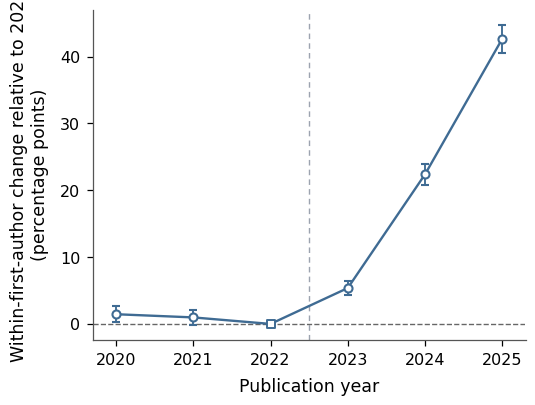

Displayed annual coefficient plot from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/annual_within_author_coefficients.csv


In [6]:
plot_data = pd.read_csv(ANNUAL_SOURCE_CSV, encoding="utf-8-sig")

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 11.5,
        "axes.labelsize": 12.5,
        "xtick.labelsize": 11.5,
        "ytick.labelsize": 11.5,
        "axes.linewidth": 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)

years = plot_data["year"].to_numpy(dtype=int)
estimates = plot_data["estimate_percentage_points"].to_numpy(float)
lower = plot_data["ci_lower_percentage_points"].to_numpy(float)
upper = plot_data["ci_upper_percentage_points"].to_numpy(float)
reference = plot_data["reference_year"].astype(bool).to_numpy()
valid = ~reference

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.axvline(
    2022.5,
    color="#9CA3AF",
    linestyle=(0, (4, 3)),
    linewidth=1.0,
    zorder=1,
)
ax.axhline(0, color="#666666", linestyle="--", linewidth=1.0, zorder=1)
ax.plot(years, estimates, color="#3F6B93", linewidth=1.7, zorder=2)
ax.errorbar(
    years[valid],
    estimates[valid],
    yerr=np.vstack(
        [
            estimates[valid] - lower[valid],
            upper[valid] - estimates[valid],
        ]
    ),
    fmt="o",
    color="#3F6B93",
    markerfacecolor="white",
    markeredgewidth=1.5,
    markersize=5.8,
    elinewidth=1.35,
    capsize=3.0,
    capthick=1.2,
    zorder=3,
)
ax.scatter(
    [EVENT_REFERENCE_YEAR],
    [0],
    marker="s",
    s=30,
    facecolor="white",
    edgecolor="#3F6B93",
    linewidth=1.4,
    zorder=4,
)
ax.set_xticks(YEARS)
ax.set_xlim(2019.7, 2025.3)
ax.set_xlabel("Publication year", labelpad=7)
ax.set_ylabel(
    "Within-first-author change relative to 2022\n(percentage points)",
    labelpad=8,
)
ax.tick_params(axis="both", length=4, width=0.9, pad=5)
ax.spines["left"].set_color("#555555")
ax.spines["bottom"].set_color("#555555")
fig.tight_layout()
plt.show()
print(f"Displayed annual coefficient plot from: {ANNUAL_SOURCE_CSV}")

## Compact reporting table

Estimates and first-author-clustered standard errors are expressed in
percentage points. The table is derived from the saved model-results
source data and is also saved as a reusable reporting table.

In [7]:
reporting_results = pd.read_csv(
    SOURCE_DATA_DIR / "author_fe_model_results.csv",
    encoding="utf-8-sig",
)

def significance_stars(p_value: float) -> str:
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""

reporting_results["Estimate (clustered SE)"] = reporting_results.apply(
    lambda row: (
        f"{row['estimate_percentage_points']:.2f}"
        f"{significance_stars(row['p_value'])} "
        f"({row['std_error_percentage_points']:.2f})"
    ),
    axis=1,
)
compact_table = reporting_results.pivot(
    index="design_label",
    columns="specification_label",
    values="Estimate (clustered SE)",
).reset_index()

COMPACT_TABLE_CSV = SOURCE_DATA_DIR / "author_fe_compact_table.csv"
compact_table.to_csv(COMPACT_TABLE_CSV, index=False, encoding="utf-8-sig")
print(f"Saved compact reporting table: {COMPACT_TABLE_CSV}")
display(compact_table)

Saved compact reporting table: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/03_author_fixed_effects/author_fe_compact_table.csv


specification_label,design_label,Author + conference + track FE,Author + conference + track FE + linear year trend,Author FE
0,Placebo cutoff 2021,-0.16 (0.29),-0.09 (0.79),-0.14 (0.29)
1,Placebo cutoff 2022,-0.19 (0.28),-0.42 (0.81),-0.16 (0.28)
2,Post-release period (2023–2025),18.31*** (0.46),-4.41*** (0.77),18.46*** (0.45)
